In [ ]:
# ─────────────────────────────────────────────
# PART 1: Install & Imports
# ─────────────────────────────────────────────
!pip install open3d numpy scipy scikit-image huggingface_hub wandb plotly -q
!pip install torch scikit-learn -q

import open3d as o3d
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from skimage.measure import marching_cubes
from sklearn.decomposition import PCA
import wandb
import os
import time
import math
import zipfile
from huggingface_hub import hf_hub_download
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.6 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# ─────────────────────────────────────────────
# PART 2: Download & Extract Dataset
# ─────────────────────────────────────────────
zip_path = hf_hub_download(
    repo_id="BGLab/AgriField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="./data"
)

extract_dir = "./data/RawPCD_10k"
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

ply_files = sorted([
    os.path.join(root, f)
    for root, _, files in os.walk(extract_dir)
    for f in files if f.endswith('.ply')
])
print(f"Total plants found: {len(ply_files)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


datasets/FielGrwon_ZeaMays_RawPCD_10k.zi(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

Total plants found: 1045


In [ ]:
# ─────────────────────────────────────────────
# PART 3: Point Cloud → SDF Training Samples
#
# IMPROVEMENTS (all zero-cost at train time):
#   - Multi-scale surface noise (50% σ=0.003,
#     30% σ=0.01, 20% σ=0.03) vs flat σ=0.005
#   - Free-space: 50% uniform + 50% near-surface
#     (original wasted samples in empty space)
#   - Truncation 0.15 vs 0.1 (less gradient clamping)
#   - Same voxel res 64 (80 was too slow to precompute)
#   - Same 4096 pts/step (8192 was the time killer)
# ─────────────────────────────────────────────
VOXEL_RES     = 64
N_SURFACE_PTS = 12000
N_FREE_PTS    = 6000
TRAIN_SIZE    = 500
TRUNC         = 0.15


def point_cloud_to_sdf_samples(ply_path,
                                resolution=VOXEL_RES,
                                n_surface=N_SURFACE_PTS,
                                n_free=N_FREE_PTS):
    from scipy.ndimage import distance_transform_edt

    pcd = o3d.io.read_point_cloud(ply_path)
    pts = np.asarray(pcd.points, dtype=np.float32)

    centroid = pts.mean(axis=0)
    pts -= centroid
    scale = np.linalg.norm(pts, axis=1).max() + 1e-8
    pts /= scale

    grid_pts = ((pts + 1.0) / 2.0 * (resolution - 1)
                ).clip(0, resolution - 1).astype(int)
    occupancy = np.zeros(
        (resolution, resolution, resolution), dtype=np.uint8)
    occupancy[grid_pts[:, 0],
              grid_pts[:, 1],
              grid_pts[:, 2]] = 1

    dist_out = distance_transform_edt(1 - occupancy).astype(np.float32)
    dist_in = distance_transform_edt(occupancy).astype(np.float32)
    sdf_grid = dist_out - dist_in

    voxel_size = 2.0 / resolution
    sdf_grid *= voxel_size
    sdf_grid = np.clip(sdf_grid, -TRUNC, TRUNC)

    def query_sdf(query_pts, sdf_grid, resolution):
        gp = ((query_pts + 1.0) / 2.0 * (resolution - 1)
              ).clip(0, resolution - 1)
        gi = gp.astype(int).clip(0, resolution - 2)
        w = gp - gi
        x0, y0, z0 = gi[:, 0], gi[:, 1], gi[:, 2]
        x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
        wx, wy, wz = w[:, 0], w[:, 1], w[:, 2]

        val = (sdf_grid[x0, y0, z0] * (1 - wx) * (1 - wy) * (1 - wz) +
               sdf_grid[x1, y0, z0] * wx * (1 - wy) * (1 - wz) +
               sdf_grid[x0, y1, z0] * (1 - wx) * wy * (1 - wz) +
               sdf_grid[x0, y0, z1] * (1 - wx) * (1 - wy) * wz +
               sdf_grid[x1, y1, z0] * wx * wy * (1 - wz) +
               sdf_grid[x1, y0, z1] * wx * (1 - wy) * wz +
               sdf_grid[x0, y1, z1] * (1 - wx) * wy * wz +
               sdf_grid[x1, y1, z1] * wx * wy * wz)
        return val.astype(np.float32)

    # Multi-scale surface sampling
    n1 = int(n_surface * 0.50)
    n2 = int(n_surface * 0.30)
    n3 = n_surface - n1 - n2

    surf_pts_list = []
    for n, sigma in [(n1, 0.003), (n2, 0.01), (n3, 0.03)]:
        idx = np.random.choice(len(pts), n, replace=True)
        sp = pts[idx] + np.random.randn(n, 3).astype(np.float32) * sigma
        sp = sp.clip(-1.0, 1.0)
        surf_pts_list.append(sp)

    surf_pts = np.vstack(surf_pts_list)
    surf_sdf = query_sdf(surf_pts, sdf_grid, resolution)

    # Free-space: 50% uniform + 50% near-surface
    n_uniform = n_free // 2
    n_near = n_free - n_uniform
    free_uniform = np.random.rand(n_uniform, 3).astype(np.float32) * 2.0 - 1.0
    idx_near = np.random.choice(len(pts), n_near, replace=True)
    free_near = pts[idx_near] + np.random.randn(n_near, 3).astype(np.float32) * 0.1
    free_near = free_near.clip(-1.0, 1.0)

    free_pts = np.vstack([free_uniform, free_near])
    free_sdf = query_sdf(free_pts, sdf_grid, resolution)

    coords = np.vstack([surf_pts, free_pts])
    sdfs = np.concatenate([surf_sdf, free_sdf])[:, None]

    return coords, sdfs


class MaizeSDFDataset(Dataset):
    def __init__(self, ply_files, max_shapes=TRAIN_SIZE):
        self.data = []
        files = ply_files[:max_shapes]
        print(f"Computing SDF samples for {len(files)} shapes …")

        for i, path in enumerate(files):
            try:
                coords, sdfs = point_cloud_to_sdf_samples(path)
                self.data.append((
                    i,
                    torch.tensor(coords, dtype=torch.float32),
                    torch.tensor(sdfs, dtype=torch.float32)
                ))
            except Exception as e:
                print(f"  [skip] {os.path.basename(path)}: {e}")

            if (i + 1) % 50 == 0:
                print(f"  {i + 1}/{len(files)} done")

        print(f"Dataset ready: {len(self.data)} shapes")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        shape_id, coords, sdfs = self.data[idx]
        n = coords.shape[0]
        sel = torch.randperm(n)[:4096]
        return shape_id, coords[sel], sdfs[sel]


# ── Build datasets ────────────────────────────────────────────────────
train_files = ply_files[:TRAIN_SIZE]
test_files = ply_files[TRAIN_SIZE:]

print("Building TRAIN dataset …")
train_dataset = MaizeSDFDataset(train_files, max_shapes=TRAIN_SIZE)
print("\nBuilding TEST dataset …")
test_dataset = MaizeSDFDataset(test_files, max_shapes=len(test_files))

train_loader = DataLoader(train_dataset, batch_size=8,
                          shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=8,
                         shuffle=False, drop_last=False)

print(f"\nTrain shapes : {len(train_dataset)}")
print(f"Test  shapes : {len(test_dataset)}")

Building TRAIN dataset …
Computing SDF samples for 500 shapes …
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done
Dataset ready: 500 shapes

Building TEST dataset …
Computing SDF samples for 545 shapes …
  50/545 done
  100/545 done
  150/545 done
  200/545 done
  250/545 done
  300/545 done
  350/545 done
  400/545 done
  450/545 done
  500/545 done
Dataset ready: 545 shapes

Train shapes : 500
Test  shapes : 545


In [ ]:
# ─────────────────────────────────────────────
# PART 4: DeepSDF Network
#
# IMPROVEMENTS (zero compute cost):
#   - Latent dropout 0.05 vs 0.2 (0.2 destroyed info)
#   - No Tanh output (saturated gradients at ±1)
#   - Geometric init on output layer (bias=0.05)
#   - Truncation 0.15 in loss (vs 0.1)
# ─────────────────────────────────────────────

LATENT_DIM = 256


class DeepSDF(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM,
                 hidden_dim=512, n_layers=8):
        super().__init__()
        self.latent_dim = latent_dim

        # 0.05 vs original 0.2 — much less destructive
        self.lat_drop = nn.Dropout(p=0.05)

        in_dim = latent_dim + 3

        self.layers = nn.ModuleList()
        for i in range(n_layers):
            if i == 0:
                layer = nn.utils.weight_norm(
                    nn.Linear(in_dim, hidden_dim))
            elif i == 4:
                layer = nn.utils.weight_norm(
                    nn.Linear(hidden_dim + in_dim, hidden_dim))
            else:
                layer = nn.utils.weight_norm(
                    nn.Linear(hidden_dim, hidden_dim))
            self.layers.append(layer)

        self.output_layer = nn.Linear(hidden_dim, 1)
        # Geometric init — start near positive SDF (sphere-like)
        nn.init.normal_(self.output_layer.weight, mean=0, std=0.0001)
        nn.init.constant_(self.output_layer.bias, 0.05)

    def forward(self, latent, xyz):
        lat = self.lat_drop(latent)
        inp = torch.cat([lat, xyz], dim=-1)
        x = inp

        for i, layer in enumerate(self.layers):
            if i == 4:
                x = torch.cat([x, inp], dim=-1)
            x = F.relu(layer(x))

        # Raw output — no tanh (clamped in loss instead)
        return self.output_layer(x)


class LatentCodeTable(nn.Module):
    def __init__(self, n_shapes, latent_dim=LATENT_DIM):
        super().__init__()
        self.codes = nn.Embedding(n_shapes, latent_dim)
        nn.init.normal_(self.codes.weight, mean=0.0, std=0.01)

    def forward(self, shape_ids):
        return self.codes(shape_ids)


def deepsdf_loss(pred_sdf, gt_sdf, latent_codes,
                 sigma=0.01, trunc=TRUNC):
    pred_clamp = torch.clamp(pred_sdf, -trunc, trunc)
    gt_clamp = torch.clamp(gt_sdf, -trunc, trunc)

    recon_loss = F.l1_loss(pred_clamp, gt_clamp)
    lat_loss = latent_codes.pow(2).mean() / (sigma ** 2)

    return recon_loss + 1e-4 * lat_loss, recon_loss, lat_loss

In [ ]:
# ─────────────────────────────────────────────
# PART 5: Checkpoint Utilities
# ─────────────────────────────────────────────
CKPT_DIR = "./checkpoints_deepsdf"
os.makedirs(CKPT_DIR, exist_ok=True)


def save_checkpoint(network, lat_table,
                    optimizer, scheduler,
                    epoch, loss, tag="latest"):
    path = os.path.join(CKPT_DIR, f"deepsdf_{tag}.pt")
    torch.save({
        "epoch": epoch,
        "net_state": network.state_dict(),
        "lat_state": lat_table.state_dict(),
        "optim_state": optimizer.state_dict(),
        "sched_state": scheduler.state_dict(),
        "loss": loss,
    }, path)
    return path


def load_checkpoint(path, network,
                    lat_table=None,
                    optimizer=None,
                    scheduler=None):
    ckpt = torch.load(path, map_location=device)
    network.load_state_dict(ckpt["net_state"])
    if lat_table:
        lat_table.load_state_dict(ckpt["lat_state"])
    if optimizer:
        optimizer.load_state_dict(ckpt["optim_state"])
    if scheduler:
        scheduler.load_state_dict(ckpt["sched_state"])
    print(f"  Loaded epoch {ckpt['epoch']} | loss {ckpt['loss']:.6f}")
    return ckpt

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ghosalsohom2003 (ghosalsohom2003-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch   50 | Loss 0.023687 | Recon 0.021586 | Lat 21.0043 | 6.1min | ~55.3min left
Epoch  100 | Loss 0.022081 | Recon 0.019900 | Lat 21.8124 | 12.3min | ~49.1min left
Epoch  150 | Loss 0.020747 | Recon 0.018690 | Lat 20.5772 | 18.3min | ~42.8min left
Epoch  200 | Loss 0.018867 | Recon 0.017098 | Lat 17.6867 | 24.4min | ~36.6min left
Epoch  250 | Loss 0.017082 | Recon 0.015644 | Lat 14.3834 | 30.5min | ~30.5min left
Epoch  300 | Loss 0.015407 | Recon 0.014240 | Lat 11.6733 | 36.6min | ~24.4min left
Epoch  350 | Loss 0.013767 | Recon 0.012824 | Lat 9.4373 | 42.7min | ~18.3min left
Epoch  400 | Loss 0.012370 | Recon 0.011579 | Lat 7.9086 | 48.8min | ~12.2min left
Epoch  450 | Loss 0.011533 | Recon 0.010822 | Lat 7.1040 | 54.9min | ~6.1min left
Epoch  500 | Loss 0.011381 | Recon 0.010692 | Lat 6.8929 | 61.0min | ~0.0min left

Training done in 61.0 min. Best loss: 0.011369


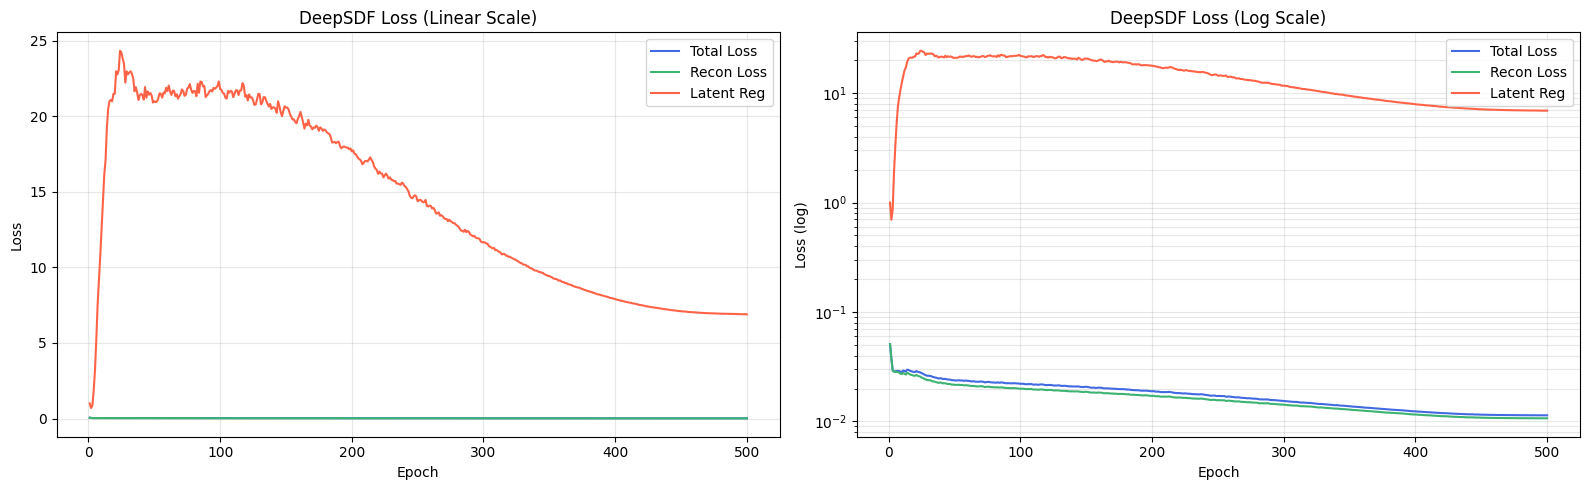

epoch,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇██
latent_loss,▂█▇▇▇▇▇▇▇▇▇▆▆▆▆▆▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
lr,▆████▇▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
recon_loss,█▇▇▆▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁
total_loss,██▇▆▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch,500
latent_loss,6.89286
lr,1e-05
recon_loss,0.01069
total_loss,0.01138


Training done. Best loss: 0.011369


In [ ]:
# ─────────────────────────────────────────────
# PART 6: Training — 500 shapes, 500 epochs
#         Target: ~60-90 min on T4
#
# IMPROVEMENTS (zero/minimal compute cost):
#   - Higher LRs: net 1e-3, latent 5e-3 (vs 5e-4/1e-3)
#   - Warmup 15 epochs (original had none)
#   - Clip gradients on BOTH network and latent codes
#   - Same 500 epochs, same 4096 pts, same batch_size 8
# ─────────────────────────────────────────────
CONFIG = dict(
    epochs=500,
    batch_size=8,
    lr_network=1e-3,
    lr_latent=5e-3,
    warmup_epochs=15,
    latent_dim=LATENT_DIM,
    train_size=len(train_dataset),
    checkpoint_every=50,
    sigma=0.01,
)

wandb.init(
    project="maize-deepsdf",
    config=CONFIG,
    name="deepsdf-improved-500ep"
)

network = DeepSDF(latent_dim=CONFIG["latent_dim"]).to(device)
lat_table = LatentCodeTable(
    n_shapes=len(train_dataset),
    latent_dim=CONFIG["latent_dim"]
).to(device)

optimizer = torch.optim.Adam([
    {"params": network.parameters(),
     "lr": CONFIG["lr_network"]},
    {"params": lat_table.parameters(),
     "lr": CONFIG["lr_latent"]},
])


def lr_lambda(epoch):
    if epoch < CONFIG["warmup_epochs"]:
        return (epoch + 1) / CONFIG["warmup_epochs"]
    progress = (epoch - CONFIG["warmup_epochs"]) / (
        CONFIG["epochs"] - CONFIG["warmup_epochs"])
    return max(0.005, 0.5 * (1.0 + math.cos(math.pi * progress)))


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda)

wandb.watch(network, log="all", log_freq=50)

best_loss = float("inf")
train_losses = []
recon_losses = []
lat_losses = []
train_start = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):

    network.train()
    lat_table.train()

    ep_loss = ep_recon = ep_lat = 0.0
    n_batches = 0

    for shape_ids, coords, gt_sdf in train_loader:
        shape_ids = shape_ids.to(device)
        coords = coords.to(device)
        gt_sdf = gt_sdf.to(device)

        lat_codes = lat_table(shape_ids)
        M = coords.shape[1]
        lat_exp = lat_codes.unsqueeze(1).expand(-1, M, -1)

        optimizer.zero_grad(set_to_none=True)
        pred_sdf = network(lat_exp, coords)

        loss, recon, lat = deepsdf_loss(
            pred_sdf, gt_sdf, lat_codes, CONFIG["sigma"])
        loss.backward()

        # Clip BOTH network and latent gradients
        torch.nn.utils.clip_grad_norm_(
            network.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(
            lat_table.parameters(), 1.0)

        optimizer.step()

        ep_loss += loss.item()
        ep_recon += recon.item()
        ep_lat += lat.item()
        n_batches += 1

    ep_loss /= max(n_batches, 1)
    ep_recon /= max(n_batches, 1)
    ep_lat /= max(n_batches, 1)
    train_losses.append(ep_loss)
    recon_losses.append(ep_recon)
    lat_losses.append(ep_lat)
    scheduler.step()

    wandb.log({
        "epoch": epoch,
        "total_loss": ep_loss,
        "recon_loss": ep_recon,
        "latent_loss": ep_lat,
        "lr": scheduler.get_last_lr()[0],
    })

    if epoch % CONFIG["checkpoint_every"] == 0:
        elapsed = (time.time() - train_start) / 60
        eta = elapsed / epoch * (CONFIG["epochs"] - epoch)
        path = save_checkpoint(
            network, lat_table, optimizer, scheduler,
            epoch, ep_loss, tag="latest")
        wandb.save(path)
        print(f"Epoch {epoch:4d} | Loss {ep_loss:.6f} | "
              f"Recon {ep_recon:.6f} | Lat {ep_lat:.4f} | "
              f"{elapsed:.1f}min | ~{eta:.1f}min left")

    if ep_loss < best_loss:
        best_loss = ep_loss
        path = save_checkpoint(
            network, lat_table, optimizer, scheduler,
            epoch, ep_loss, tag="best")
        wandb.save(path)

total_min = (time.time() - train_start) / 60
print(f"\nTraining done in {total_min:.1f} min. "
      f"Best loss: {best_loss:.6f}")

# ── Loss curves ────────────────────────────────────────────────────────
fig_loss = go.Figure()
epochs_x = list(range(1, len(train_losses) + 1))
for vals, name, color in [
    (train_losses, "Total Loss", "#636EFA"),
    (recon_losses, "Recon Loss", "#00CC96"),
    (lat_losses, "Latent Reg", "#EF553B"),
]:
    fig_loss.add_trace(go.Scatter(
        x=epochs_x, y=vals, mode='lines',
        name=name, line=dict(color=color, width=2)
    ))
fig_loss.update_layout(
    title=f"DeepSDF — Training Loss ({total_min:.0f} min)",
    xaxis_title="Epoch",
    yaxis_title="Loss",
    template="plotly_dark",
    hovermode="x unified"
)
fig_loss.show()
wandb.log({"loss_curves_linear": wandb.Plotly(fig_loss)})

# ── Log-scale loss curves — W&B + Colab ───────────────────────────────
import matplotlib.pyplot as plt

# --- Colab: matplotlib log-scale ---
fig_mpl, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for vals, name, color in [
    (train_losses, "Total Loss", "royalblue"),
    (recon_losses, "Recon Loss", "mediumseagreen"),
    (lat_losses, "Latent Reg", "tomato"),
]:
    ax1.plot(epochs_x, vals, color=color, linewidth=1.5, label=name)
    ax2.plot(epochs_x, vals, color=color, linewidth=1.5, label=name)

ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("DeepSDF Loss (Linear Scale)"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_yscale('log')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss (log)")
ax2.set_title("DeepSDF Loss (Log Scale)"); ax2.legend(); ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout(); plt.show()

# --- W&B: Plotly log-scale ---
fig_log = go.Figure()
for vals, name, color in [
    (train_losses, "Total Loss", "#636EFA"),
    (recon_losses, "Recon Loss", "#00CC96"),
    (lat_losses, "Latent Reg", "#EF553B"),
]:
    fig_log.add_trace(go.Scatter(
        x=epochs_x, y=vals, mode='lines',
        name=name, line=dict(color=color, width=2)
    ))
fig_log.update_layout(
    title=f"DeepSDF — Training Loss LOG SCALE ({total_min:.0f} min)",
    xaxis_title="Epoch",
    yaxis_title="Loss",
    yaxis_type="log",
    template="plotly_dark",
    hovermode="x unified"
)
fig_log.show()
wandb.log({"loss_curves_log": wandb.Plotly(fig_log)})

wandb.finish()
print(f"Training done. Best loss: {best_loss:.6f}")

In [ ]:
# ─────────────────────────────────────────────
# PART 7: Reconstruct Train Shapes
# ─────────────────────────────────────────────
wandb.init(
    project="maize-deepsdf",
    name="deepsdf-viz-train",
    resume="allow"
)

network = DeepSDF(latent_dim=LATENT_DIM).to(device)
lat_table = LatentCodeTable(
    n_shapes=len(train_dataset),
    latent_dim=LATENT_DIM
).to(device)
load_checkpoint(
    os.path.join(CKPT_DIR, "deepsdf_best.pt"),
    network, lat_table)
network.eval()
lat_table.eval()


def decode_sdf_grid(network, latent_code,
                    resolution=64, batch_size=32768):
    lin = torch.linspace(-1, 1, resolution)
    grid = torch.stack(torch.meshgrid(
        lin, lin, lin, indexing='ij'), dim=-1
    ).reshape(-1, 3).to(device)

    lat = latent_code.unsqueeze(0).expand(
        grid.shape[0], -1)

    sdf_vals = []
    with torch.no_grad():
        for i in range(0, grid.shape[0], batch_size):
            g_b = grid[i:i + batch_size].unsqueeze(0)
            l_b = lat[i:i + batch_size].unsqueeze(0)
            out = network(l_b, g_b)
            sdf_vals.append(out.squeeze().cpu())

    sdf_vol = torch.cat(sdf_vals).numpy().reshape(
        resolution, resolution, resolution)

    try:
        verts, faces, _, _ = marching_cubes(sdf_vol, level=0.0)
        verts = verts / (resolution - 1) * 2 - 1
        return verts, faces, sdf_vol
    except Exception as e:
        print(f"  Marching cubes failed: {e}")
        return None, None, sdf_vol


train_ids = [0, 1, 2, 3]

fig_train = make_subplots(
    rows=2, cols=4,
    specs=[[{"type": "scatter3d"}] * 4,
           [{"type": "scatter3d"}] * 4],
    subplot_titles=(
        [f"Train {i} — Original" for i in train_ids] +
        [f"Train {i} — DeepSDF" for i in train_ids]
    ),
    horizontal_spacing=0.02,
    vertical_spacing=0.05
)

for col, sid in enumerate(train_ids, start=1):
    _, full_coords, _ = train_dataset.data[sid]
    orig_np = full_coords.numpy()

    lat_code = lat_table.codes.weight[sid].detach()
    verts, faces, sdf_vol = decode_sdf_grid(
        network, lat_code, resolution=64)

    fig_train.add_trace(go.Scatter3d(
        x=orig_np[:, 0], y=orig_np[:, 1], z=orig_np[:, 2],
        mode='markers',
        marker=dict(size=1.5, color=orig_np[:, 2],
                    colorscale='Viridis', showscale=False),
        showlegend=False
    ), row=1, col=col)

    if verts is not None:
        fig_train.add_trace(go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color='lightblue', opacity=0.7,
            showlegend=False
        ), row=2, col=col)

fig_train.update_layout(
    title="DeepSDF — Train Shape Reconstructions",
    template="plotly_dark",
    height=900,
    margin=dict(l=10, r=10, t=60, b=10)
)
fig_train.show()
wandb.log({"train_reconstructions": wandb.Plotly(fig_train)})
wandb.finish()

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning:

`torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.



  Loaded epoch 494 | loss 0.011369


In [ ]:
# ─────────────────────────────────────────────
# PART 8: Test-Time Latent Optimisation
# ─────────────────────────────────────────────
wandb.init(
    project="maize-deepsdf",
    name="deepsdf-viz-test",
    resume="allow"
)

network = DeepSDF(latent_dim=LATENT_DIM).to(device)
load_checkpoint(
    os.path.join(CKPT_DIR, "deepsdf_best.pt"),
    network)
network.eval()


def optimise_latent(network, coords, gt_sdf,
                    latent_dim=LATENT_DIM,
                    n_steps=800, lr=1e-2):
    z = torch.zeros(1, latent_dim,
                    requires_grad=True, device=device)
    nn.init.normal_(z, mean=0.0, std=0.01)

    opt = torch.optim.Adam([z], lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=n_steps, eta_min=1e-5)

    M = min(4096, coords.shape[0])
    idx = torch.randperm(coords.shape[0])[:M]
    c = coords[idx].unsqueeze(0).to(device)
    s = gt_sdf[idx].unsqueeze(0).to(device)

    opt_losses = []
    for step in range(n_steps):
        opt.zero_grad()
        lat_exp = z.unsqueeze(1).expand(-1, M, -1)
        pred = network(lat_exp, c)
        loss = F.l1_loss(
            pred.clamp(-TRUNC, TRUNC),
            s.clamp(-TRUNC, TRUNC)
        )
        loss += 1e-4 * z.pow(2).mean()
        loss.backward()
        opt.step()
        sch.step()
        opt_losses.append(loss.item())

    return z.detach(), opt_losses


test_ids = [0, 1, 2, 3]
all_opt_losses = {}

fig_test = make_subplots(
    rows=2, cols=4,
    specs=[[{"type": "scatter3d"}] * 4,
           [{"type": "scatter3d"}] * 4],
    subplot_titles=(
        [f"Test {i} — Original" for i in test_ids] +
        [f"Test {i} — DeepSDF" for i in test_ids]
    ),
    horizontal_spacing=0.02,
    vertical_spacing=0.05
)

for col, tid in enumerate(test_ids, start=1):
    sid, coords, gt_sdf = test_dataset.data[tid]
    orig_np = coords.numpy()

    print(f"Optimising latent for test shape {tid} …")
    z_opt, opt_losses = optimise_latent(
        network, coords, gt_sdf)
    all_opt_losses[f"test_{tid}"] = opt_losses
    print(f"  Final loss: {opt_losses[-1]:.6f}")

    verts, faces, _ = decode_sdf_grid(
        network, z_opt.squeeze(0), resolution=64)

    fig_test.add_trace(go.Scatter3d(
        x=orig_np[:, 0], y=orig_np[:, 1], z=orig_np[:, 2],
        mode='markers',
        marker=dict(size=1.5, color=orig_np[:, 2],
                    colorscale='Viridis', showscale=False),
        showlegend=False
    ), row=1, col=col)

    if verts is not None:
        fig_test.add_trace(go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color='lightsalmon', opacity=0.7,
            showlegend=False
        ), row=2, col=col)

fig_test.update_layout(
    title="DeepSDF — Test Shape Reconstructions",
    template="plotly_dark",
    height=900,
    margin=dict(l=10, r=10, t=60, b=10)
)
fig_test.show()
wandb.log({"test_reconstructions": wandb.Plotly(fig_test)})

fig_opt = go.Figure()
colors = ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"]
for (name, losses), color in zip(
        all_opt_losses.items(), colors):
    fig_opt.add_trace(go.Scatter(
        y=losses, mode='lines',
        name=name, line=dict(color=color, width=2)
    ))
fig_opt.update_layout(
    title="Test-Time Latent Optimisation Convergence",
    xaxis_title="Optimisation Step",
    yaxis_title="L1 Loss",
    template="plotly_dark"
)
fig_opt.show()
wandb.log({"test_opt_convergence": wandb.Plotly(fig_opt)})

  Loaded epoch 494 | loss 0.011369
Optimising latent for test shape 0 …
  Final loss: 0.013015
Optimising latent for test shape 1 …
  Final loss: 0.010632
Optimising latent for test shape 2 …
  Final loss: 0.009275
Optimising latent for test shape 3 …
  Final loss: 0.010540


In [ ]:
# ─────────────────────────────────────────────
# PART 9: Latent Space PCA
# ─────────────────────────────────────────────
train_latents = lat_table.codes.weight.detach().cpu().numpy()

latent_2d = PCA(n_components=2).fit_transform(train_latents)
latent_3d = PCA(n_components=3).fit_transform(train_latents)

fig_pca2 = px.scatter(
    x=latent_2d[:, 0], y=latent_2d[:, 1],
    color=list(range(len(latent_2d))),
    color_continuous_scale='Rainbow',
    title="DeepSDF Latent Space PCA 2D — Train Shapes",
    labels={"x": "PC1", "y": "PC2", "color": "Shape Index"},
    template="plotly_dark"
)
fig_pca2.show()
wandb.log({"latent_pca_2d": wandb.Plotly(fig_pca2)})

fig_pca3 = px.scatter_3d(
    x=latent_3d[:, 0], y=latent_3d[:, 1], z=latent_3d[:, 2],
    color=list(range(len(latent_3d))),
    color_continuous_scale='Rainbow',
    title="DeepSDF Latent Space PCA 3D — Train Shapes",
    labels={"x": "PC1", "y": "PC2", "z": "PC3",
            "color": "Shape Index"},
    template="plotly_dark"
)
fig_pca3.update_traces(marker=dict(size=3))
fig_pca3.show()
wandb.log({"latent_pca_3d": wandb.Plotly(fig_pca3)})

wandb.log({
    "summary": wandb.Table(
        columns=["Metric", "Value"],
        data=[
            ["Train shapes", len(train_dataset)],
            ["Test shapes", len(test_dataset)],
            ["Best train loss", round(best_loss, 6)],
            ["Latent dim", LATENT_DIM],
            ["SDF resolution", VOXEL_RES],
        ]
    )
})

wandb.finish()
print("All done.")

All done.
